# Offline CV-RAG Results with Enriched Incident Context

This notebook is the full-offline scenario: the device has a local image/text case pack, regenerated illustrative images, local CLIP embeddings, a SQLite vector store, and Phi-4-mini-style answer drafting from retrieved evidence. The incident text was regenerated with the `gpt-5.4-mini` deployment, while the images were regenerated locally from the enriched captions and visual clues because `MAI-Image-2.5-Flash` quota in South Central US is fully consumed for this subscription.

## What got indexed into the local vector store

The offline pack contains only the six `offline_seed_enriched` records. Each image was regenerated from the enriched `image_caption` and `visual_clues`, then indexed together with the incident text. The vector stored in SQLite is the same fused representation used by the runtime: `0.65 * image_embedding + 0.35 * incident_text_embedding`.

| ID | Image | Severity | Visual clues | Root-cause hypothesis |
| --- | --- | --- | --- | --- |
| INC-001 | ![INC-001](assets/cv_rag_enriched/images/inc_001_basement_wall_water_ingress_observed_at_cons.png) | high | Dark damp streaks on cast wall surface, Visible drips at construction joint, Efflorescence near joint line | Likely discontinuity in waterproofing membrane, inadequate joint preparation, or failed waterstop/sealant at a construction joint combined with hydrostatic pressure. |
| INC-002 | ![INC-002](assets/cv_rag_enriched/images/inc_002_concrete_column_honeycombing_detected_after_.png) | high | Exposed coarse aggregate, Voids and honeycombed surface texture, Minor grout leakage marks | Probable inadequate vibration, congested reinforcement impeding flow, grout loss through formwork joints, or improper concrete placement technique. |
| INC-003 | ![INC-003](assets/cv_rag_enriched/images/inc_003_rebar_congestion_visible_at_beam_column_join.png) | medium | Closely spaced longitudinal bars, Crowded stirrups and ties, Reduced clear space for concrete flow | Likely a combination of design-dense reinforcement at a highly loaded joint and insufficient constructability coordination between structural detailing and placement method. |
| INC-004 | ![INC-004](assets/cv_rag_enriched/images/inc_004_mep_duct_coordination_clash_at_ceiling_void.png) | medium | Duct occupies intended ceiling zone, Adjacent services have minimal clearance, Hangers and supports appear tightly packed | Likely incomplete coordination of MEP trades, late design revisions, or insufficient clash detection before installation. |
| INC-005 | ![INC-005](assets/cv_rag_enriched/images/inc_005_unsafe_open_edge_adjacent_to_scaffold_access.png) | critical | Open edge without top rail or mid-rail, Scaffold access ladder or landing nearby, No visible toe board at edge | Likely removal or omission of edge protection during sequencing, inadequate supervision, or incomplete scaffold-to-structure interface controls. |
| INC-006 | ![INC-006](assets/cv_rag_enriched/images/inc_006_hairline_crack_observed_near_lift_core_wall_.png) | medium | Fine line crack near corner, No visible offset between surfaces, Localized around opening or stress concentration | Possible shrinkage crack, restraint from adjacent pours, temporary load transfer effects, or stress concentration at an opening corner. |

## Local vector store shape

| Field | Meaning |
| --- | --- |
| `incident_id` | Stable citation ID returned to Phi-4-mini and shown to the worker. |
| `payload_json` | Enriched incident title, severity, observation, visual clues, root-cause hypothesis, checklist, and escalation rule. |
| `image_path` | Regenerated image cached in the offline pack. |
| `vector_json` | 512-dimensional CLIP fused image/text vector for the prototype; production should replace JSON vectors with `sqlite-vec` or USearch. |


## Regenerated example images

The cell output embeds the images directly so GitHub renders them even if relative notebook image links are not expanded.

INC-001 - Basement wall water ingress observed at construction joint


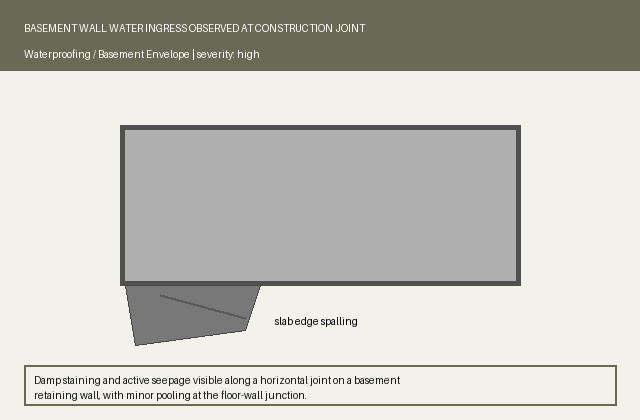

INC-002 - Concrete column honeycombing detected after form removal


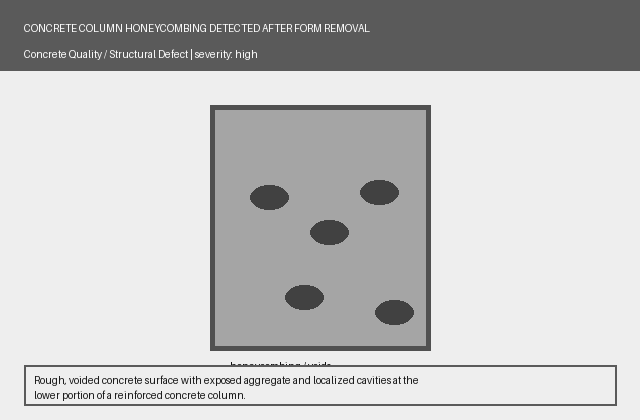

INC-003 - Rebar congestion visible at beam-column joint


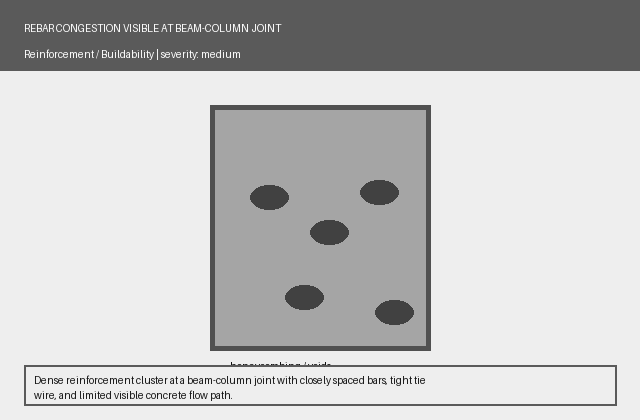

INC-004 - MEP duct coordination clash at ceiling void


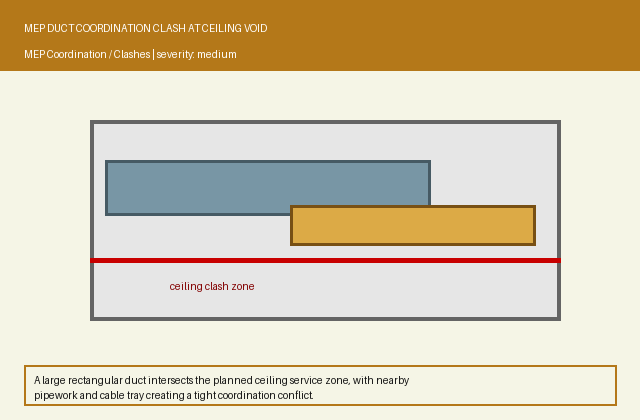

INC-005 - Unsafe open edge adjacent to scaffold access point


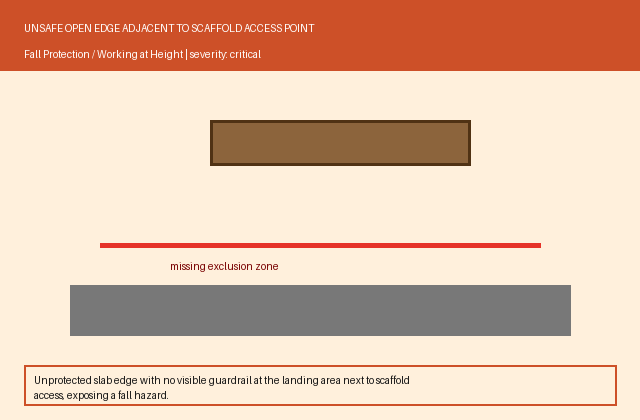

INC-006 - Hairline crack observed near lift core wall opening


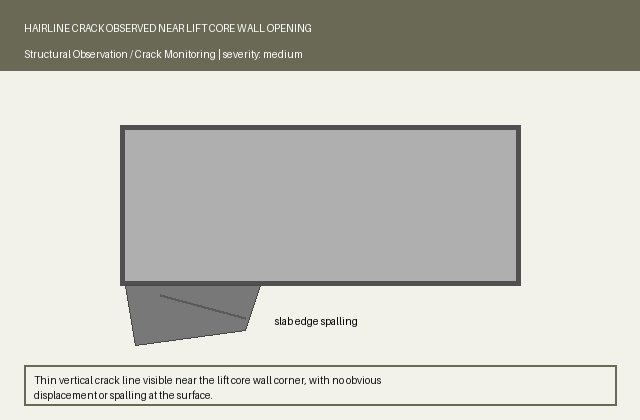

In [1]:
from IPython.display import Image, display

image_rows = [
    ("INC-001", "Basement wall water ingress observed at construction joint", "assets/cv_rag_enriched/images/inc_001_basement_wall_water_ingress_observed_at_cons.png"),
    ("INC-002", "Concrete column honeycombing detected after form removal", "assets/cv_rag_enriched/images/inc_002_concrete_column_honeycombing_detected_after_.png"),
    ("INC-003", "Rebar congestion visible at beam-column joint", "assets/cv_rag_enriched/images/inc_003_rebar_congestion_visible_at_beam_column_join.png"),
    ("INC-004", "MEP duct coordination clash at ceiling void", "assets/cv_rag_enriched/images/inc_004_mep_duct_coordination_clash_at_ceiling_void.png"),
    ("INC-005", "Unsafe open edge adjacent to scaffold access point", "assets/cv_rag_enriched/images/inc_005_unsafe_open_edge_adjacent_to_scaffold_access.png"),
    ("INC-006", "Hairline crack observed near lift core wall opening", "assets/cv_rag_enriched/images/inc_006_hairline_crack_observed_near_lift_core_wall_.png"),
]
for incident_id, title, path in image_rows:
    print(f"{incident_id} - {title}")
    display(Image(filename=path, width=320))


In [2]:
import json
from pathlib import Path

summary = json.loads(Path("assets/cv_rag_enriched/offline_eval_report_summary.json").read_text())
print(f"Indexed offline cases: {summary['indexed_count']}")
print(f"Example queries: {len(summary['queries'])}")
print(f"Top-1 retrieval accuracy on this synthetic pack: {summary['top1_accuracy']:.1%}")


Indexed offline cases: 6
Example queries: 6
Top-1 retrieval accuracy on this synthetic pack: 100.0%


## Offline query results

| Scenario | Expected | Top hit | Top 3 retrieved cases |
| --- | --- | --- | --- |
| basement water ingress | INC-001 | INC-001 | INC-001, INC-006, INC-003 |
| column honeycombing | INC-002 | INC-002 | INC-002, INC-006, INC-003 |
| rebar congestion | INC-003 | INC-003 | INC-003, INC-005, INC-002 |
| MEP ceiling clash | INC-004 | INC-004 | INC-004, INC-006, INC-001 |
| open edge hazard | INC-005 | INC-005 | INC-005, INC-006, INC-003 |
| lift core crack | INC-006 | INC-006 | INC-006, INC-005, INC-002 |

## Where Phi-4-mini helps in the offline path

Phi-4-mini does not replace retrieval. The mobile runtime first uses CLIP embeddings and the local vector store to find compact evidence. Phi-4-mini then reads only the top retrieved cases and drafts a worker-facing response: what the top visual match is, what to do next, what to escalate, and which case IDs support the answer.

This is why full fine-tuning is not required for the first POC: the model only needs to follow an evidence-grounded answer contract. The case knowledge stays in the vector pack and can be updated without retraining.

## Example Phi-4-mini evidence prompt and answer

**Evidence prompt shape sent to Phi-4-mini**

```text
Retrieved evidence:
[INC-002] title=Concrete column honeycombing detected after form removal; severity=high; visual_clues=Exposed coarse aggregate, Voids and honeycombed surface texture, Minor grout leakage marks, Irregular finish at column corner; observation=A reinforced concrete column shows honeycombing in the lower lift area following formwork removal. The defect is localized but extends over enough surface area to indicate poor consolidation or leakage during casting, requiring assessment of depth and impact on cover.; root_cause=Probable inadequate vibration, congested reinforcement impeding flow, grout loss through formwork joints, or improper concrete placement technique.; actions=Sound the affected area and carry out a depth assessment by engineer or competent inspector.; Verify reinforcement cover and determine whether structural repair is required.; Review pour sequence, vibration records, and formwork tightness for the affected lift.; Protect the area from impact and restrict loading until disposition is confirmed.; Prepare a repair method statement if patching, epoxy injection, or breakout and reinstatement is needed.; escalation=Escalate to structural engineer immediately if defect depth approaches reinforcement, cover is compromised, or multiple columns exhibit similar honeycombing.

Question:
A column face has honeycombing, exposed aggregate, and rough voids after formwork striking. What should we do?
```

**Phi-4-mini-style answer from local evidence**

Top visual match is `INC-002` (`Concrete column honeycombing detected after form removal`). Treat it as a concrete quality defect and do not cover or load-transfer through the affected area until the defect is assessed.

1. Sound the affected area and carry out a depth assessment by engineer or competent inspector.
1. Verify reinforcement cover and determine whether structural repair is required.
1. Review pour sequence, vibration records, and formwork tightness for the affected lift.
1. Protect the area from impact and restrict loading until disposition is confirmed.
1. Prepare a repair method statement if patching, epoxy injection, or breakout and reinstatement is needed.

Escalate when: Escalate to structural engineer immediately if defect depth approaches reinforcement, cover is compromised, or multiple columns exhibit similar honeycombing.

Citation: `INC-002`.